In [ ]:
import numpy as np
class Linear_Regression():
  def __init__(self, Learning_rate, No_of_iterations):
    self.Learning_rate = Learning_rate
    self.No_of_iterations = No_of_iterations

  def fit(self, X, Y):
    self.m, self.n = X.shape

    self.w = np.zeros(self.n)
    self.b = 0
    self.X = X
    self.Y = Y

    for i in range(self.No_of_iterations):
      self.update_weights()

  def update_weights(self):
    Y_prediction = self.predict(self.X)

    error = Y_prediction - self.Y
    dw = (2 / self.m) * self.X.T.dot(error)
    db = (2 / self.m) * np.sum(error)

    self.w = self.w - self.Learning_rate * dw
    self.b = self.b - self.Learning_rate * db

  def predict(self, X):
    return X.dot(self.w) + self.b

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import Linear_Regression_model as LR

In [ ]:
salary_data = pd.read_csv('/content/salary_data.csv')

In [ ]:
print(salary_data.head(5))

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [ ]:
print(salary_data.tail(5))

    YearsExperience  Salary
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872


In [ ]:
salary_data.shape

(30, 2)

In [ ]:
print(salary_data.isnull().sum())

YearsExperience    0
Salary             0
dtype: int64


In [ ]:
X = salary_data.iloc[:, :-1].values
Y = salary_data.iloc[:, 1].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.33, random_state=2)

In [ ]:
model = LR.Linear_Regression(Learning_rate = .02, No_of_iterations = 1000)

In [ ]:
model.fit(X_train, Y_train)

In [ ]:
print(model.w[0])
print(model.b)

9514.400999035135
23697.406507136307


In [ ]:
Y_data_prediction = model.predict(X_test)
print(Y_data_prediction)
print(Y_test)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]
[ 46205  39343  61111  57189  98273  93940 113812  60150  43525  91738]


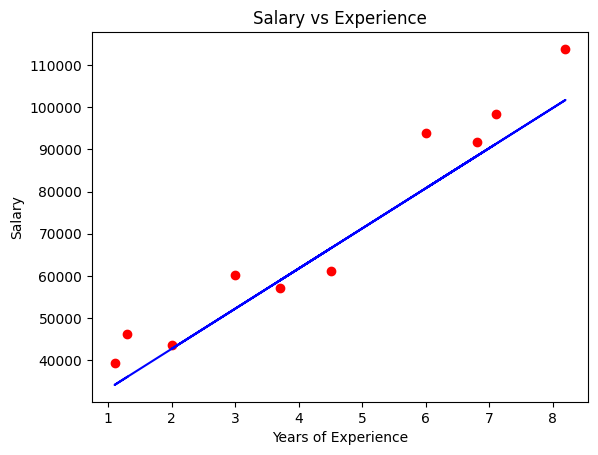

In [ ]:
plt.scatter(X_test, Y_test, color='red')
plt.plot(X_test, Y_data_prediction, color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()